# Прогнозирование оттока клиентов e-commerce-сервиса

Этот ноутбук оформлен как учебный ML-проект. Цель проекта — построить модель машинного обучения, которая прогнозирует отток клиентов e-commerce-сервиса, и объяснить, какие признаки сильнее всего связаны с уходом клиентов.

В проекте используется бинарная классификация: `Churn = 1` означает, что клиент ушёл, `Churn = 0` — клиент остался.

## План работы

1. Загрузить данные и изучить структуру датасета.
2. Проверить пропуски, дубликаты и баланс целевой переменной.
3. Провести EDA и сформулировать выводы.
4. Проверить три гипотезы статистическими тестами.
5. Подготовить признаки для обучения моделей.
6. Обучить Logistic Regression, Decision Tree, Random Forest и Gradient Boosting.
7. Выполнить подбор гиперпараметров для лучшей модели.
8. Интерпретировать важность признаков.
9. Сохранить финальный pipeline через `joblib`.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 100)

mkdir -p failed for path C:\Users\kasa0\.matplotlib: [WinError 5] Отказано в доступе: 'C:\\Users\\kasa0\\.matplotlib'


Matplotlib created a temporary cache directory at C:\Users\kasa0\AppData\Local\Temp\matplotlib-42x6hmuc because there was an issue with the default path (C:\Users\kasa0\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Загрузка данных

Датасет находится в папке `data` в формате Excel. Ноутбук лежит в папке `notebooks`, поэтому путь к данным указан как `../data/...`. Для чтения используем обычный `pandas.read_excel` с движком `openpyxl`.

In [2]:
DATA_PATH = '../data/E Commerce Dataset.xlsx'
MODEL_PATH = '../models/best_churn_model.pkl'

In [3]:
df_raw = pd.read_excel(DATA_PATH, sheet_name='E Comm', engine='openpyxl')
data_dict = pd.read_excel(DATA_PATH, sheet_name='Data Dict', engine='openpyxl')

df_raw.shape

(5630, 20)

In [4]:
df_raw.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
data_dict.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


## Описание датасета и признаков

Датасет содержит информацию о клиентах e-commerce-сервиса: срок использования сервиса, предпочитаемые устройства и способы оплаты, активность заказов, жалобы, расстояние до склада, кешбэк и другие признаки.

Целевая переменная — `Churn`:

- `0` — клиент остался;
- `1` — клиент ушёл.

Основные признаки:

- `Tenure` — срок жизни клиента в сервисе;
- `PreferredLoginDevice` — предпочитаемое устройство входа;
- `CityTier` — уровень города;
- `WarehouseToHome` — расстояние от склада до дома клиента;
- `PreferredPaymentMode` — предпочитаемый способ оплаты;
- `Gender` — пол клиента;
- `HourSpendOnApp` — время в приложении;
- `NumberOfDeviceRegistered` — количество зарегистрированных устройств;
- `PreferedOrderCat` — предпочитаемая категория заказа;
- `SatisfactionScore` — оценка удовлетворённости;
- `MaritalStatus` — семейное положение;
- `NumberOfAddress` — количество адресов;
- `Complain` — была ли жалоба;
- `OrderAmountHikeFromlastYear` — рост суммы заказа относительно прошлого года;
- `CouponUsed` — количество использованных купонов;
- `OrderCount` — количество заказов;
- `DaySinceLastOrder` — дней с последнего заказа;
- `CashbackAmount` — сумма кешбэка.

`CustomerID` является идентификатором клиента и не должен использоваться как обучающий признак.

In [6]:
display(df_raw.head())
display(data_dict.head(25))

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


## Первичный осмотр данных

На этом этапе проверим размер таблицы, типы данных, пропуски, дубликаты и баланс целевой переменной. Эти проверки помогают понять, какая предобработка понадобится перед обучением моделей.

In [7]:
df = df_raw.copy()

summary = pd.DataFrame({
    'column': df.columns,
    'dtype': [df[col].dtype for col in df.columns],
    'missing': [df[col].isna().sum() for col in df.columns],
    'missing_rate': [df[col].isna().mean() for col in df.columns],
    'unique_values': [df[col].nunique(dropna=True) for col in df.columns]
})

display(pd.DataFrame({'rows': [df.shape[0]], 'columns': [df.shape[1]], 'duplicates': [df.duplicated().sum()]}))
display(summary)
display(df['Churn'].value_counts(normalize=True).rename('share').to_frame())

,rows,columns,duplicates
0,5630,20,0


,column,dtype,missing,missing_rate,unique_values
0,CustomerID,int64,0,0.000000,5630
1,Churn,int64,0,0.000000,2
2,Tenure,float64,264,0.046892,36
3,PreferredLoginDevice,str,0,0.000000,3
4,CityTier,int64,0,0.000000,3
5,WarehouseToHome,float64,251,0.044583,34
6,PreferredPaymentMode,str,0,0.000000,7
7,Gender,str,0,0.000000,2
8,HourSpendOnApp,float64,255,0.045293,6
9,NumberOfDeviceRegistered,int64,0,0.000000,6


,share
Churn,
0,0.831616
1,0.168384


В датасете 5630 строк и 20 колонок. Дубликаты после первичной проверки не обнаружены. Пропуски есть в нескольких числовых признаках, поэтому в ML-пайплайне их нужно заполнить медианой. Доля клиентов с оттоком составляет около 16.8%, поэтому классы несбалансированы.

## EDA: распределение целевой переменной

Сначала посмотрим, насколько часто встречается отток. Для задач churn это важный шаг: если ушедших клиентов намного меньше, чем оставшихся, одной accuracy может быть недостаточно.

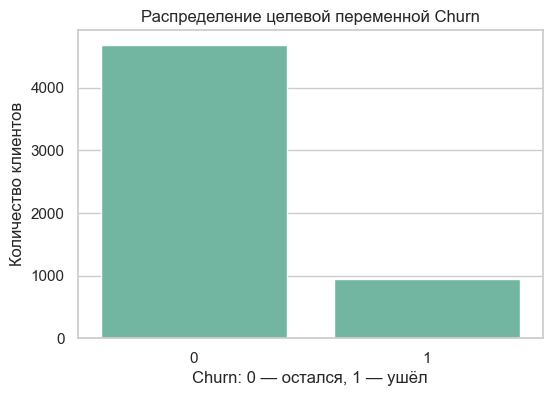

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn')
ax.set_title('Распределение целевой переменной Churn')
ax.set_xlabel('Churn: 0 — остался, 1 — ушёл')
ax.set_ylabel('Количество клиентов')
plt.show()

Класс `0` заметно преобладает: большинство клиентов не ушли. Это означает, что при оценке моделей важно смотреть не только на accuracy, но и на recall, precision, F1-score и ROC-AUC.

## EDA: распределение числовых признаков

Посмотрим на несколько числовых признаков, которые могут быть связаны с поведением клиента: срок жизни, время в приложении, количество заказов и кешбэк.

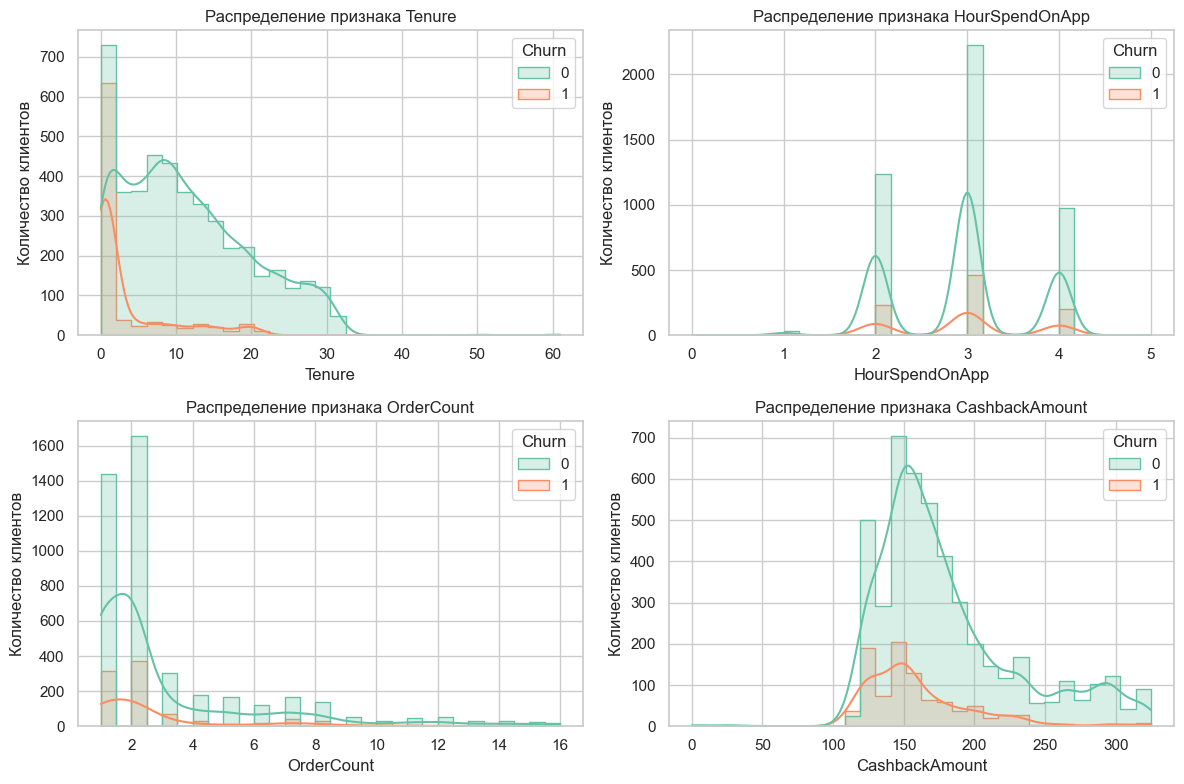

In [9]:
numeric_for_plot = ['Tenure', 'HourSpendOnApp', 'OrderCount', 'CashbackAmount']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_for_plot):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True, ax=ax, element='step')
    ax.set_title(f'Распределение признака {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()

На графиках видно, что `Tenure` особенно важен: среди ушедших клиентов много пользователей с небольшим сроком жизни. По `OrderCount` различия слабее, а `CashbackAmount` и активность заказов требуют проверки вместе с другими признаками.

## EDA: категориальные признаки и Churn

Теперь сравним долю оттока в нескольких группах клиентов. Такой график удобен для поиска сегментов, где риск ухода выше.

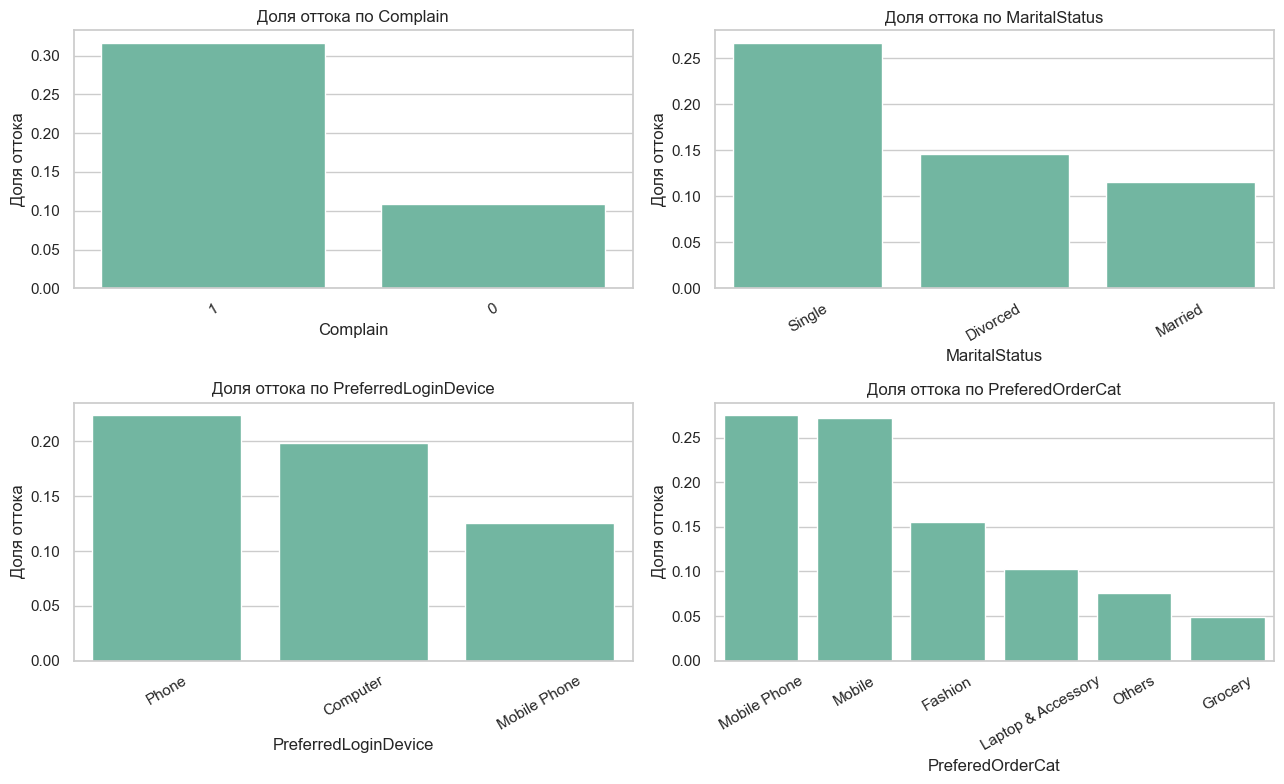

In [10]:
categorical_for_plot = ['Complain', 'MaritalStatus', 'PreferredLoginDevice', 'PreferedOrderCat']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, col in zip(axes, categorical_for_plot):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values, ax=ax)
    ax.set_title(f'Доля оттока по {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Доля оттока')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Самое заметное различие наблюдается у признака `Complain`: клиенты с жалобами уходят чаще. Также видны отличия по семейному положению, устройству входа и предпочитаемой категории заказа, но эти связи нужно оценивать вместе с остальными признаками.

## EDA: корреляционная матрица

Корреляционная матрица помогает увидеть линейные связи между числовыми признаками и целевой переменной. Это не доказывает причинность, но даёт полезные ориентиры для анализа.

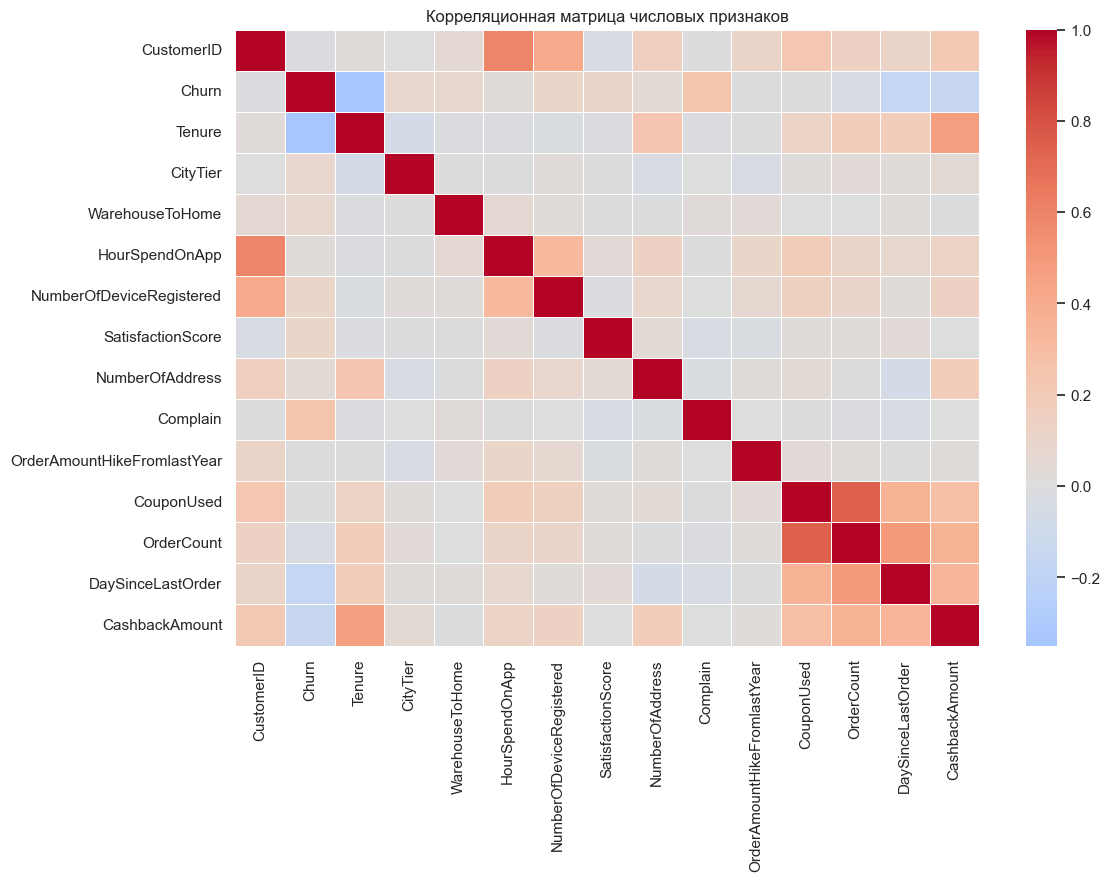

In [11]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

`Churn` сильнее всего визуально связан с `Tenure` и `Complain`. Отрицательная связь с `Tenure` логична: чем дольше клиент пользуется сервисом, тем ниже риск ухода. Положительная связь с `Complain` показывает, что жалобы могут быть важным сигналом риска.

## EDA: churn rate по группам клиентов

Сравним отток по группам, которые проще интерпретировать бизнесу: срок жизни клиента, время с последнего заказа и уровень кешбэка.

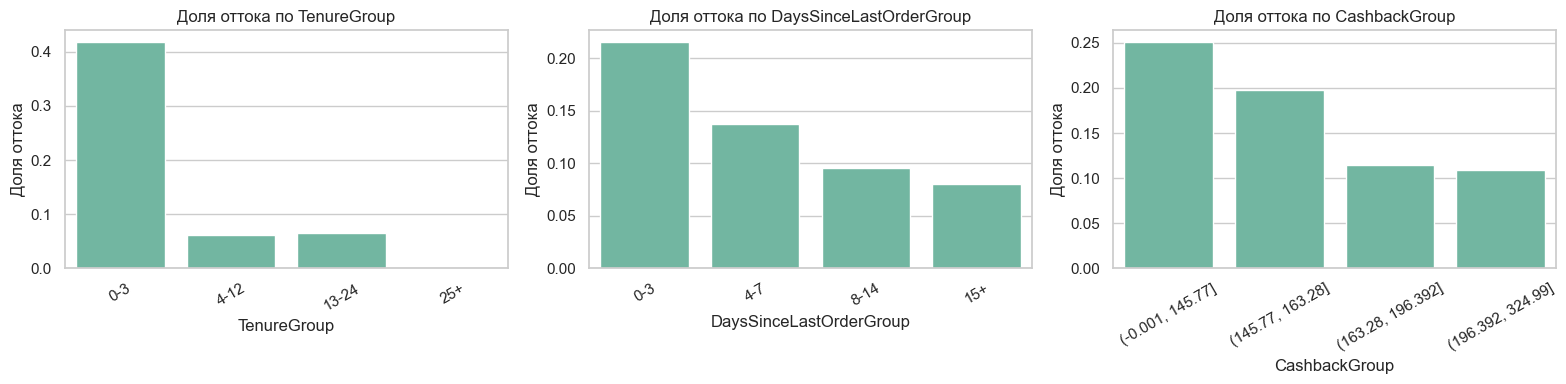

In [12]:
group_df = df.copy()
group_df['TenureGroup'] = pd.cut(group_df['Tenure'], bins=[-1, 3, 12, 24, 100], labels=['0-3', '4-12', '13-24', '25+'])
group_df['DaysSinceLastOrderGroup'] = pd.cut(group_df['DaySinceLastOrder'], bins=[-1, 3, 7, 14, 60], labels=['0-3', '4-7', '8-14', '15+'])
group_df['CashbackGroup'] = pd.qcut(group_df['CashbackAmount'], q=4, duplicates='drop')

group_cols = ['TenureGroup', 'DaysSinceLastOrderGroup', 'CashbackGroup']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, group_cols):
    churn_rate = group_df.groupby(col, observed=False)['Churn'].mean()
    sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values, ax=ax)
    ax.set_title(f'Доля оттока по {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Доля оттока')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Самый высокий churn rate виден у клиентов с коротким `Tenure`. Это важный практический вывод: ранний период жизни клиента может быть критичным для удержания. Различия по времени с последнего заказа и кешбэку тоже есть, но выглядят менее однозначно.

## Выводы после EDA

1. Отток является несбалансированным классом: ушедших клиентов меньше, поэтому accuracy нельзя использовать как единственную метрику.
2. Короткий срок использования сервиса (`Tenure`) выглядит одним из главных сигналов оттока.
3. Жалобы (`Complain`) заметно связаны с более высокой долей ухода клиентов.
4. Поведенческие признаки вроде `OrderCount`, `DaySinceLastOrder`, `CouponUsed` и `CashbackAmount` могут быть полезны в модели, особенно в комбинации друг с другом.
5. Для обучения нужен pipeline с заполнением пропусков, кодированием категорий и масштабированием числовых признаков.

## Проверка гипотез

Проверим три простые гипотезы. Для категориального признака используем критерий хи-квадрат, а для числовых признаков — непараметрический тест Манна — Уитни, потому что распределения признаков не обязаны быть нормальными.

In [13]:
hypothesis_results = []

complain_table = pd.crosstab(df['Complain'], df['Churn'])
chi2_stat, p_complain, dof, expected = chi2_contingency(complain_table)
hypothesis_results.append({
    'hypothesis': 'Жалобы и отток связаны',
    'test': 'Хи-квадрат',
    'p_value': p_complain
})

tenure_churn = df.loc[df['Churn'] == 1, 'Tenure'].dropna()
tenure_keep = df.loc[df['Churn'] == 0, 'Tenure'].dropna()
tenure_stat, p_tenure = mannwhitneyu(tenure_churn, tenure_keep, alternative='less')
hypothesis_results.append({
    'hypothesis': 'Tenure у ушедших клиентов меньше',
    'test': 'Манна — Уитни',
    'p_value': p_tenure
})

order_churn = df.loc[df['Churn'] == 1, 'OrderCount'].dropna()
order_keep = df.loc[df['Churn'] == 0, 'OrderCount'].dropna()
order_stat, p_order = mannwhitneyu(order_churn, order_keep, alternative='less')
hypothesis_results.append({
    'hypothesis': 'OrderCount у ушедших клиентов меньше',
    'test': 'Манна — Уитни',
    'p_value': p_order
})

hypothesis_results = pd.DataFrame(hypothesis_results)
display(hypothesis_results)

,hypothesis,test,p_value
0,Жалобы и отток связаны,Хи-квадрат,2.664461e-78
1,Tenure у ушедших клиентов меньше,Манна — Уитни,2.840262e-193
2,OrderCount у ушедших клиентов меньше,Манна — Уитни,1.818220e-02


### Гипотеза 1: клиенты с жалобами чаще уходят

- H0: наличие жалобы и факт оттока независимы.
- H1: наличие жалобы связано с оттоком клиента.
- Использованный тест: критерий хи-квадрат для таблицы сопряжённости.
- p-value: `2.66e-78`.
- Вывод: p-value намного меньше 0.05, поэтому H0 отвергается. В данных клиенты с жалобами действительно уходят чаще.

### Гипотеза 2: клиенты с меньшим сроком использования сервиса чаще уходят

- H0: распределение `Tenure` у ушедших и оставшихся клиентов не отличается в сторону меньших значений у ушедших.
- H1: у ушедших клиентов `Tenure` меньше.
- Использованный тест: тест Манна — Уитни.
- p-value: `2.84e-193`.
- Вывод: p-value намного меньше 0.05, поэтому H0 отвергается. Клиенты с коротким сроком жизни заметно чаще попадают в отток.

### Гипотеза 3: менее активные клиенты чаще уходят

В качестве простого показателя активности используем `OrderCount`.

- H0: распределение `OrderCount` у ушедших и оставшихся клиентов не отличается в сторону меньших значений у ушедших.
- H1: у ушедших клиентов `OrderCount` меньше.
- Использованный тест: тест Манна — Уитни.
- p-value: `0.0182`.
- Вывод: p-value меньше 0.05, поэтому статистически различие есть. При этом медианы близки, значит эффект выглядит слабее, чем у `Tenure` и `Complain`.

## Подготовка данных для ML

Перед обучением удалим дубликаты, отделим целевую переменную и исключим `CustomerID`. Пропуски в числовых признаках будут заполнены медианой, категориальные признаки — самым частым значением. Категории кодируются через One-Hot Encoding, а числовые признаки масштабируются, чтобы Logistic Regression работала корректнее.

In [14]:
df_model = df.drop_duplicates().copy()

target = 'Churn'
id_col = 'CustomerID'

X = df_model.drop(columns=[target, id_col])
y = df_model[target].astype(int)

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

numeric_features, categorical_features

(['Tenure',
  'CityTier',
  'WarehouseToHome',
  'HourSpendOnApp',
  'NumberOfDeviceRegistered',
  'SatisfactionScore',
  'NumberOfAddress',
  'Complain',
  'OrderAmountHikeFromlastYear',
  'CouponUsed',
  'OrderCount',
  'DaySinceLastOrder',
  'CashbackAmount'],
 ['PreferredLoginDevice',
  'PreferredPaymentMode',
  'Gender',
  'PreferedOrderCat',
  'MaritalStatus'])

## Обучение моделей

Сравним четыре модели: Logistic Regression как baseline, Decision Tree, Random Forest и Gradient Boosting. Все модели обучаются через единый `Pipeline`, чтобы предобработка выполнялась одинаково и не было утечки данных из test-части.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

results = []
fitted_models = {}

for name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    metrics = evaluate_model(pipeline, X_test, y_test)
    results.append({'model': name, **metrics})

model_results = pd.DataFrame(results).set_index('model').sort_values('ROC-AUC', ascending=False)
display(model_results)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
model,,,,,
Random Forest,0.975133,0.993902,0.857895,0.920904,0.998248
Gradient Boosting,0.914742,0.809211,0.647368,0.719298,0.945012
Decision Tree,0.960036,0.879581,0.884211,0.881890,0.929819
Logistic Regression,0.790409,0.437158,0.842105,0.575540,0.886224


Лучший результат по ROC-AUC показал `Random Forest`: ROC-AUC около 0.998 и F1-score около 0.921. Для задачи оттока особенно важно не пропускать клиентов с риском ухода, поэтому стоит смотреть на recall и F1-score, а ROC-AUC использовать как общую оценку качества ранжирования клиентов по риску. `Random Forest` выбран как лучшая базовая модель, потому что он одновременно даёт высокий ROC-AUC, высокий F1-score и хорошую точность по классу оттока.

## Подбор гиперпараметров

Для лучшей модели выполним `GridSearchCV`. Подбор делаем небольшим, чтобы проект оставался учебным и быстро воспроизводимым.

In [16]:
best_model_name = model_results.index[0]

param_grids = {
    'Logistic Regression': {
        'model__C': [0.1, 1, 3]
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, 8, None],
        'model__min_samples_leaf': [1, 3, 5]
    },
    'Random Forest': {
        'model__n_estimators': [100, 150],
        'model__max_depth': [None, 8, 12],
        'model__min_samples_leaf': [1, 3]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 150],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3]
    }
}

grid_search = GridSearchCV(
    fitted_models[best_model_name],
    param_grids[best_model_name],
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
tuned_metrics = evaluate_model(tuned_model, X_test, y_test)
comparison = pd.DataFrame([
    {'version': 'До настройки', **model_results.loc[best_model_name].to_dict()},
    {'version': 'После настройки', **tuned_metrics}
]).set_index('version')

display(pd.DataFrame([grid_search.best_params_]))
display(comparison)

,model__max_depth,model__min_samples_leaf,model__n_estimators
0,None,1,150


,Accuracy,Precision,Recall,F1-score,ROC-AUC
version,,,,,
До настройки,0.975133,0.993902,0.857895,0.920904,0.998248
После настройки,0.971581,0.993750,0.836842,0.908571,0.998372


После настройки ROC-AUC немного вырос, но recall и F1-score стали ниже. Для задачи оттока это важный сигнал: нам нужно не только хорошо ранжировать клиентов по риску, но и находить как можно больше клиентов, которые действительно уйдут. Лучшие параметры в поиске: `max_depth=None`, `min_samples_leaf=1`, `n_estimators=150`, но как финальную модель разумнее оставить базовую версию `Random Forest`, потому что она лучше по F1-score и recall.

## Интерпретация лучшей модели

Для `Random Forest` можно посмотреть важность признаков. Важность показывает, какие признаки модель чаще использовала для разделения клиентов, но не является доказательством причинно-следственной связи.

,feature,importance
0,num__Tenure,0.242968
12,num__CashbackAmount,0.095700
2,num__WarehouseToHome,0.061889
7,num__Complain,0.059847
11,num__DaySinceLastOrder,0.058000
6,num__NumberOfAddress,0.051868
8,num__OrderAmountHikeFromlastYear,0.048807
5,num__SatisfactionScore,0.045245
4,num__NumberOfDeviceRegistered,0.032108
10,num__OrderCount,0.029830


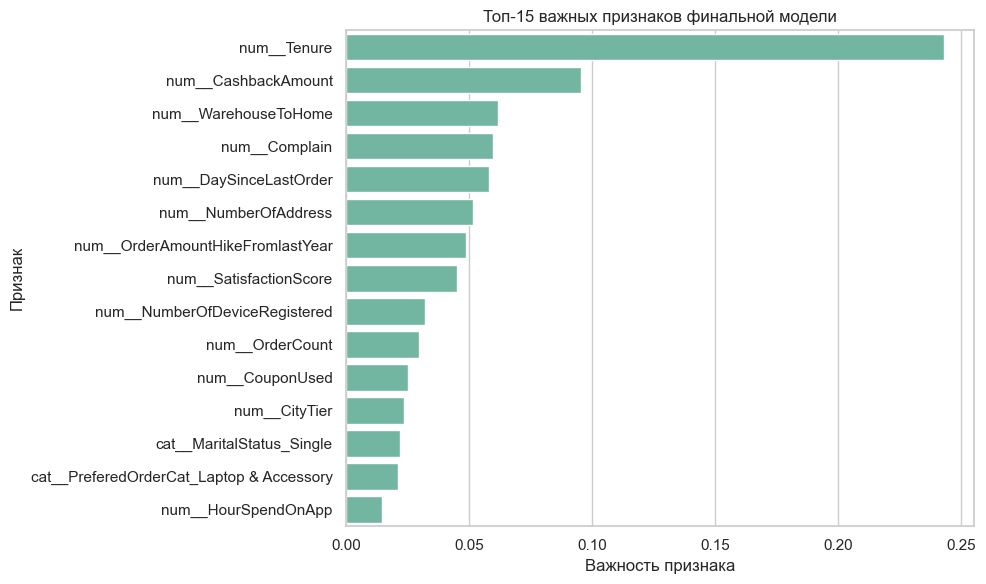

In [17]:
final_model = tuned_model if comparison.loc['После настройки', 'F1-score'] >= comparison.loc['До настройки', 'F1-score'] else fitted_models[best_model_name]

feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
model_step = final_model.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
else:
    importances = np.abs(model_step.coef_[0])

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Топ-15 важных признаков финальной модели')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

Самым важным признаком оказался `Tenure`: короткий срок жизни клиента сильнее всего связан с риском оттока. Также в топе находятся `CashbackAmount`, `Complain`, `WarehouseToHome`, `DaySinceLastOrder`, `NumberOfAddress` и `OrderAmountHikeFromlastYear`. Жалобы и большой период с последнего заказа могут повышать вероятность ухода, а более длительный `Tenure` выглядит признаком удержания. Кешбэк, количество адресов и расстояние до склада могут отражать разные пользовательские сегменты и особенности клиентского опыта.

## Сохранение модели

Сохраним финальный pipeline целиком. Это важно: внутри pipeline уже есть заполнение пропусков, масштабирование числовых признаков, кодирование категорий и обученная модель. Такой объект можно применять к новым данным без ручного повторения предобработки.

In [18]:
joblib.dump(final_model, MODEL_PATH)
MODEL_PATH

'../models/best_churn_model.pkl'

## Итоговый вывод

В проекте был построен полный базовый ML-пайплайн для прогнозирования оттока клиентов e-commerce-сервиса. Лучшей моделью стала `Random Forest`, которая показала высокий ROC-AUC и хороший F1-score на тестовой выборке.

Основные факторы, связанные с оттоком:

1. `Tenure` — новые клиенты уходят чаще, поэтому раннее удержание особенно важно.
2. `Complain` — жалобы заметно связаны с повышенным риском ухода.
3. `DaySinceLastOrder`, `OrderCount`, `CashbackAmount` и другие поведенческие признаки помогают модели лучше отделять клиентов с риском оттока.

С практической точки зрения бизнесу стоит уделять внимание клиентам с коротким сроком жизни, клиентам с жалобами и клиентам, которые давно не совершали заказ. Модель можно использовать как базовый инструмент для приоритизации retention-коммуникаций.